# Warum deutsche Lehrer individuelle Förderung nicht leisten können.
Wie hat sich das Verhältnis zwischen wachsender Heterogenität in deutschen Schulklassen und verfügbarer Lehrerkapazität in den letzten Jahren entwickelt – und was zeigen die Leistungsergebnisse?

## Storyline

1. Angela Merkel Zitat
2. Schüler pro Lehrer nimmt ab
3. Das ist aber vefälscht durch  z.B. Teilzeitarbeitskräft, Krankheitstage
4. Außerdem höherer Anteil an Kindern mit Förderbedarf, für die Lehrer evtl. nicht ausreichend ausgebildet sind
5. Insgesamt gibt es deswegen einen Mangel von ... der sich bis 2035 auf prognostiziert ... verändern wird

## Anzahl Schüler vs. Leher

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('Statistiken')
F_LEHRER = DATA / 'Lehrer an allgemeinbildenden Schulen.xlsx'
F_SCHUELER = DATA / 'Schüler an allgemeinbildenden Schulen.xlsx'

In [ ]:
def load(path):
    df = (pd.read_excel(path, sheet_name='Daten', header=None, usecols=[1, 2], skiprows=5)
            .dropna())
    df.columns = ['Schuljahr', 'Anzahl']
    return df.astype({'Anzahl': int}).reset_index(drop=True)

lehrer = load(F_LEHRER).rename(columns={'Anzahl': 'Lehrkraefte'})
schueler = load(F_SCHUELER).rename(columns={'Anzahl': 'Schueler'})

df = schueler.merge(lehrer, on='Schuljahr', how='inner').sort_values('Schuljahr').reset_index(drop=True)
df

,Schuljahr,Schueler,Lehrkraefte
0,2010/11,8796894,763988
1,2011/12,8678196,760491
2,2012/13,8556879,759136
3,2013/14,8420111,752830
4,2014/15,8366666,752358
5,2015/16,8335061,754726
6,2016/17,8369513,759051
7,2017/18,8346707,763266
8,2018/19,8330457,773280
9,2019/20,8326884,782610


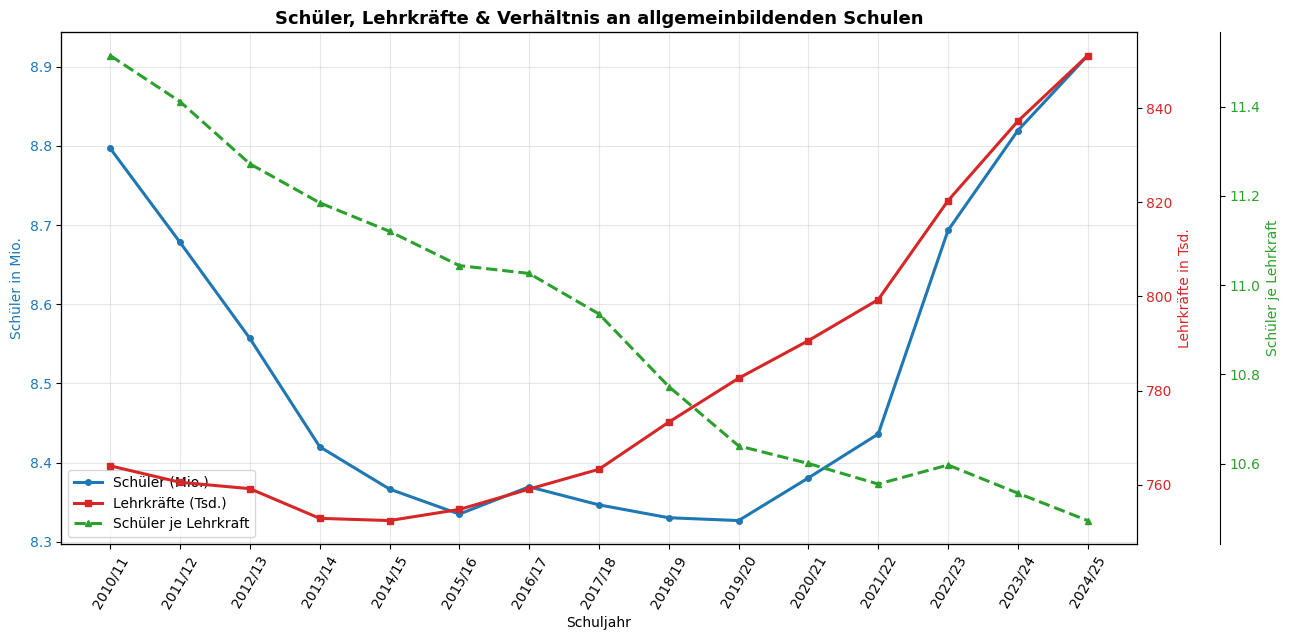

In [ ]:
df['SchuelerProLehrer'] = df['Schueler'] / df['Lehrkraefte']

fig, ax1 = plt.subplots(figsize=(13, 6.5))

color_s = '#1f77b4'
color_l = '#d62728'
color_r = '#2ca02c'

ax1.plot(df['Schuljahr'], df['Schueler'] / 1e6, color=color_s, linewidth=2.2, marker='o', markersize=4, label='Schüler (Mio.)')
ax1.set_xlabel('Schuljahr')
ax1.set_ylabel('Schüler in Mio.', color=color_s)
ax1.tick_params(axis='y', labelcolor=color_s)
ax1.tick_params(axis='x', rotation=60)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df['Schuljahr'], df['Lehrkraefte'] / 1000, color=color_l, linewidth=2.2, marker='s', markersize=4, label='Lehrkräfte (Tsd.)')
ax2.set_ylabel('Lehrkräfte in Tsd.', color=color_l)
ax2.tick_params(axis='y', labelcolor=color_l)

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(df['Schuljahr'], df['SchuelerProLehrer'], color=color_r, linewidth=2.2, marker='^', markersize=4, linestyle='--', label='Schüler je Lehrkraft')
ax3.set_ylabel('Schüler je Lehrkraft', color=color_r)
ax3.tick_params(axis='y', labelcolor=color_r)

lines = ax1.get_lines() + ax2.get_lines() + ax3.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='lower left')

plt.title('Schüler, Lehrkräfte & Verhältnis an allgemeinbildenden Schulen', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
ratio = df.dropna().assign(SchuelerProLehrer=lambda d: d['Schueler'] / d['Lehrkraefte'])
print(ratio[['Schuljahr', 'SchuelerProLehrer']].to_string(index=False, float_format=lambda x: f'{x:.1f}'))

Schuljahr  SchuelerProLehrer
  2010/11               11.5
  2011/12               11.4
  2012/13               11.3
  2013/14               11.2
  2014/15               11.1
  2015/16               11.0
  2016/17               11.0
  2017/18               10.9
  2018/19               10.8
  2019/20               10.6
  2020/21               10.6
  2021/22               10.6
  2022/23               10.6
  2023/24               10.5
  2024/25               10.5
